In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# UMAP (install if needed: pip install umap-learn)
try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap

In [2]:
# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target
labels = iris.target_names

## PCA realization

In [3]:
# Standartization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Helper Function for Plotting
def plot_embedding(X_embedded, title):
    plt.figure()
    for i in range(len(labels)):
        plt.scatter(X_embedded[y == i, 0], X_embedded[y == i, 1], label=labels[i])
    plt.legend()
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

Explained variance ratio: [0.72962445 0.22850762]


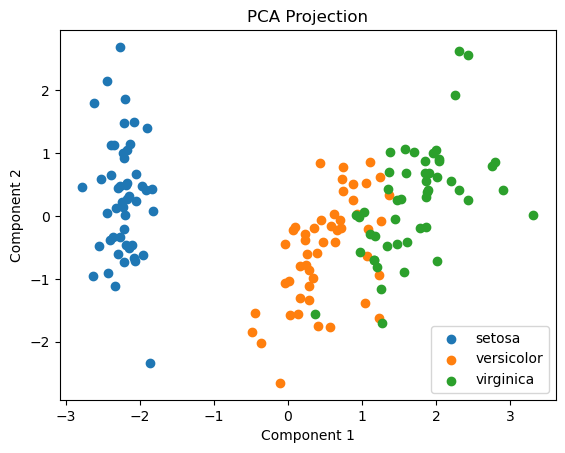

In [5]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
plot_embedding(X_pca, "PCA Projection")

## t-SNE (t-Distributed Stochastic Neighbour Embedding)

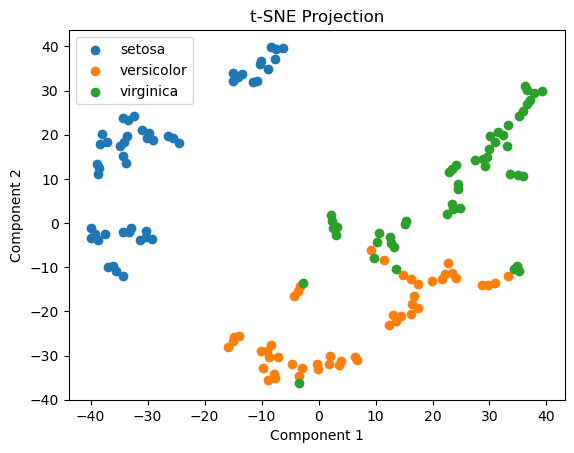

In [6]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plot_embedding(X_tsne, "t-SNE Projection")

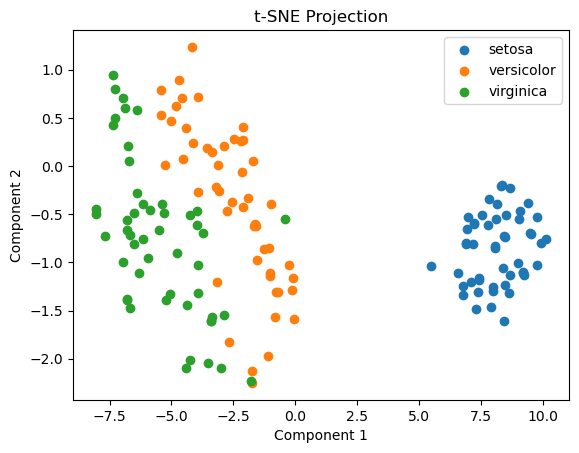

In [7]:
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plot_embedding(X_tsne, "t-SNE Projection")

## UMAP (Uniform Manifold Approximation and Projection )

C:\Users\vira.liubchenko\AppData\Local\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


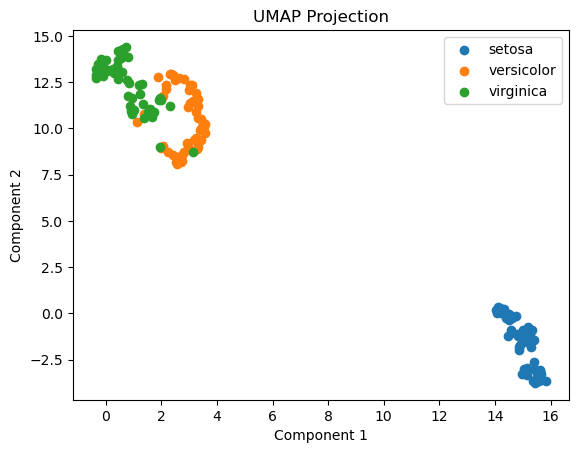

In [8]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plot_embedding(X_umap, "UMAP Projection")